In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [ ]:
# read the data
data = pd.read_csv("/content/drive/My Drive/foodhub_order.csv")
#print(data)
# returns the first 5 rows
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [ ]:
# Write your code here
# Checking the number of rows and columns
num_rows, num_columns = data.shape

# Print the result
print(f"The dataset has {num_rows} rows and {num_columns} columns.")


The dataset has 1898 rows and 9 columns.


In [ ]:
# Use info() to print a concise summary of the DataFrame
# Displaying information about the data types and non-null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [ ]:
# Write your code here
# Checking for missing values
missing_values = data.isnull().sum()

# Displaying columns with missing values
print("Columns with missing values:")
print(missing_values[missing_values > 0])

# Handling missing values
# Filling missing values with the mean of the column
data.fillna(data.mean(), inplace=True)



Columns with missing values:
Series([], dtype: int64)


<ipython-input-8-df1e4f08d02c>:11: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data.fillna(data.mean(), inplace=True)


In [ ]:
# Write your code here
# Displaying statistical summary for food preparation time
food_preparation_summary = data['food_preparation_time'].describe()

# Printing the results
print("Statistical Summary for Food Preparation Time:")
print(food_preparation_summary)

# Accessing specific statistics
min_preparation_time = food_preparation_summary['min']
avg_preparation_time = food_preparation_summary['mean']
max_preparation_time = food_preparation_summary['max']

# Printing the minimum, average, and maximum food preparation time
print(f"Minimum Food Preparation Time: {min_preparation_time} minutes")
print(f"Average Food Preparation Time: {avg_preparation_time} minutes")
print(f"Maximum Food Preparation Time: {max_preparation_time} minutes")


Statistical Summary for Food Preparation Time:
count    1898.000000
mean       27.371970
std         4.632481
min        20.000000
25%        23.000000
50%        27.000000
75%        31.000000
max        35.000000
Name: food_preparation_time, dtype: float64
Minimum Food Preparation Time: 20.0 minutes
Average Food Preparation Time: 27.371970495258168 minutes
Maximum Food Preparation Time: 35.0 minutes


In [ ]:
# Write the code here
# Counting the number of orders with no ratings
unrated_orders=[]
print(data['rating'].value_counts())
unrated_orders = data[(data['rating'].isnull()) & (data['cost_of_the_order'].notnull())].shape[0]

#Not given
# Print the result
print(f"The number of orders not rated/rating='Not given': {unrated_orders}")

5.0    588
4.0    386
3.0    188
Name: rating, dtype: int64
The number of orders not rated: 736


### Exploratory Data Analysis (EDA)

### Univariate Analysis

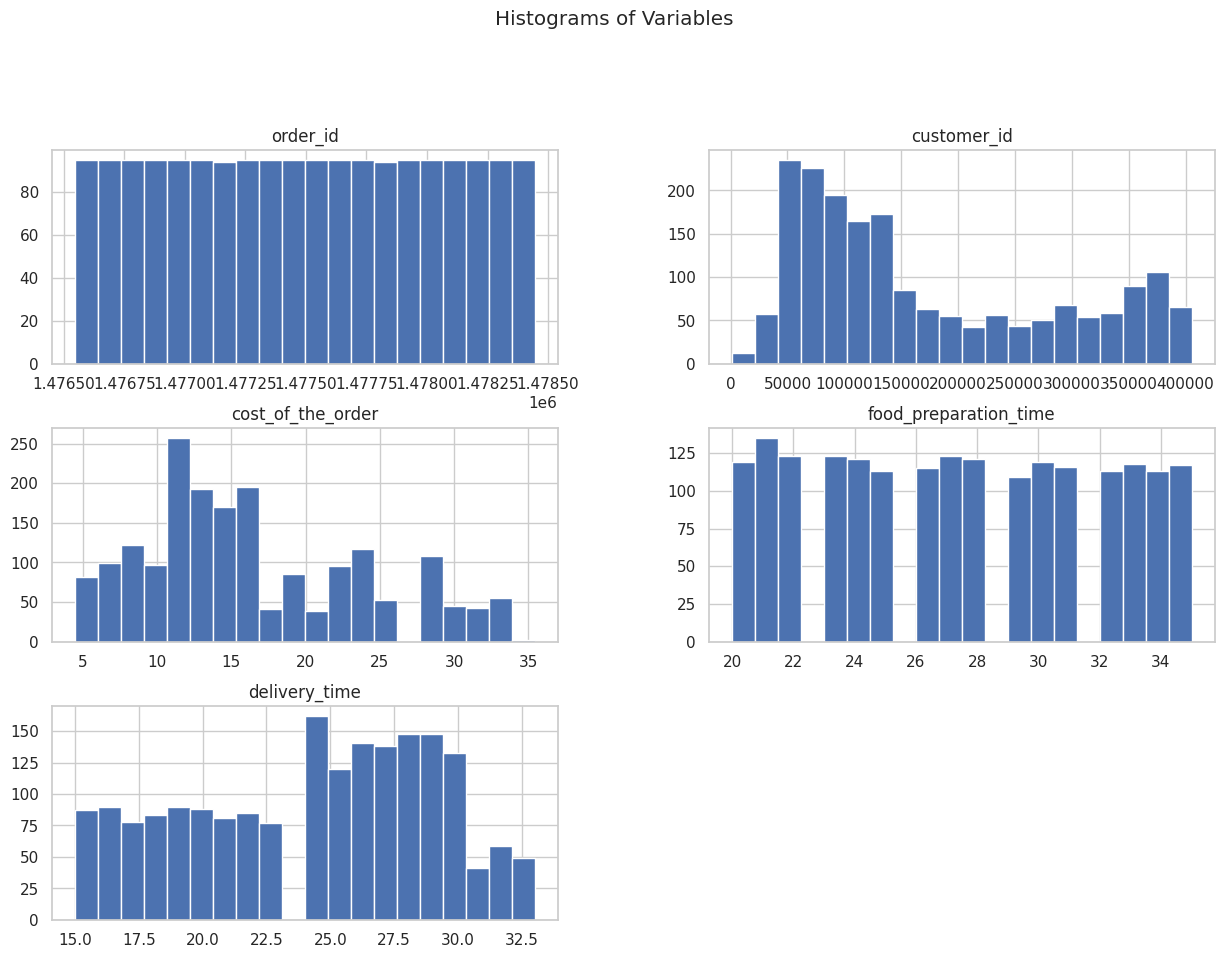

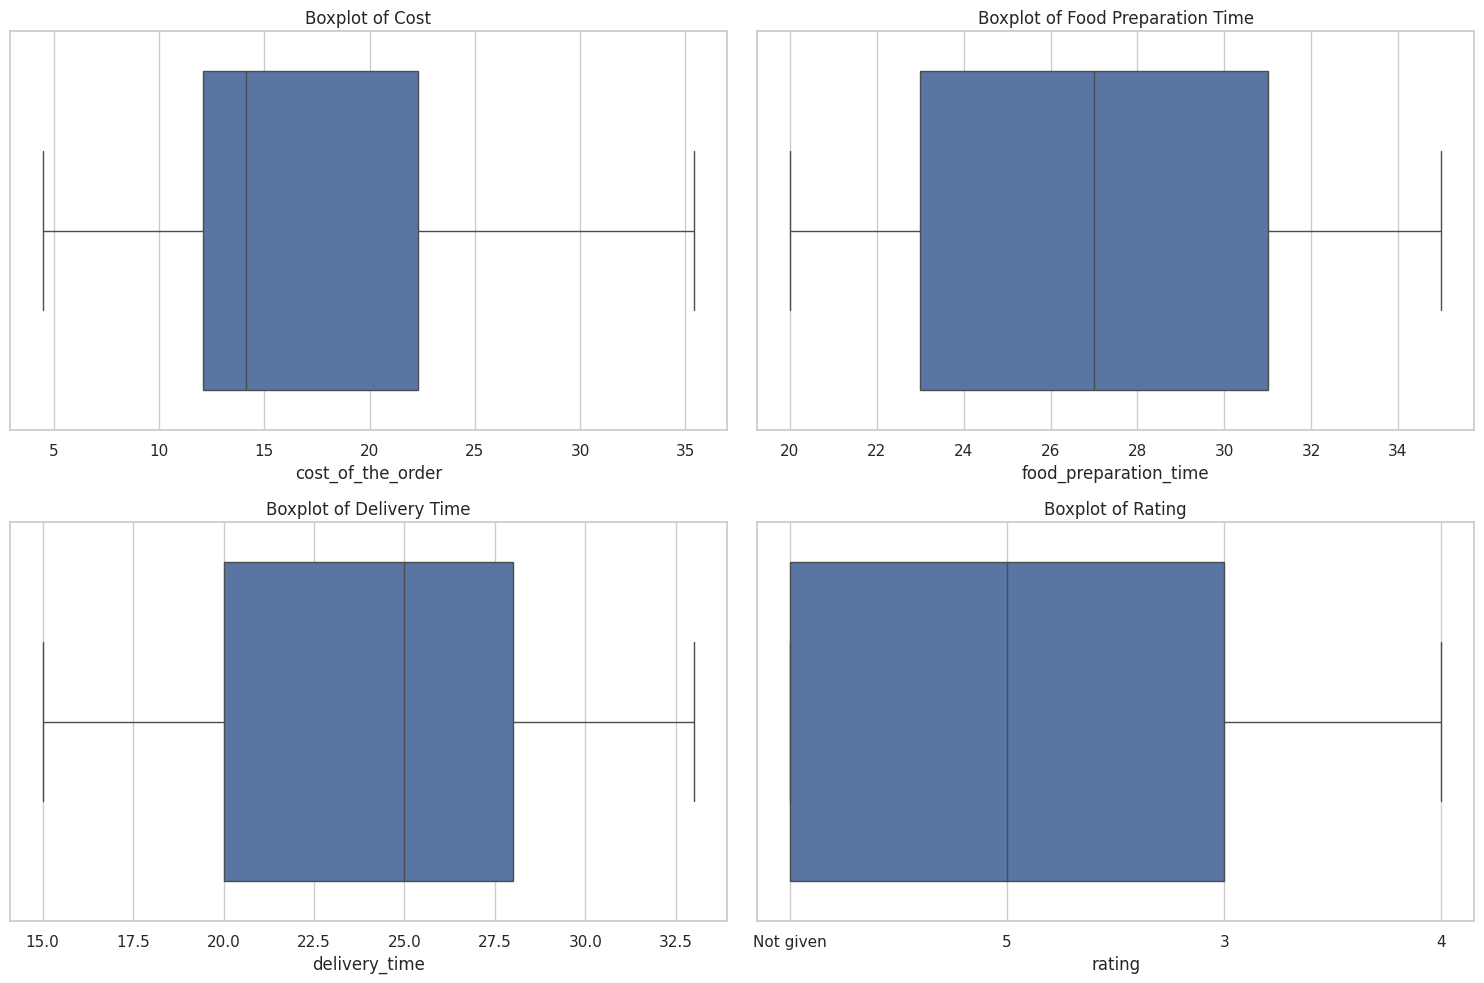

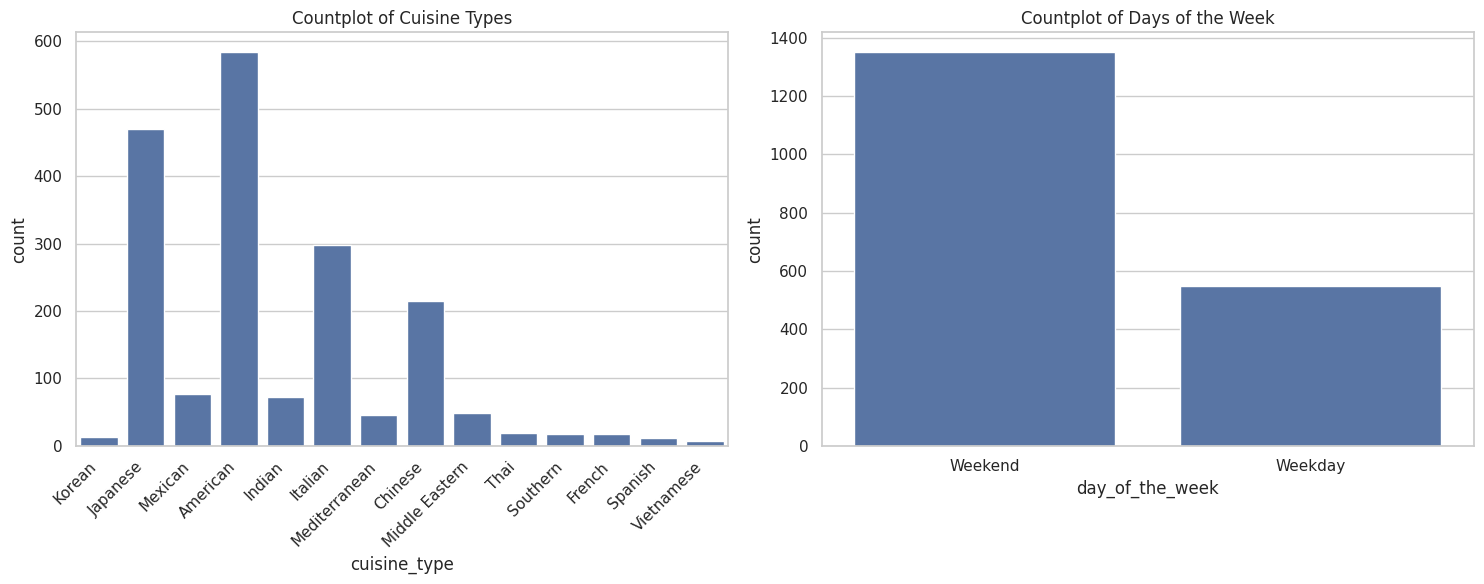

In [ ]:
# Write the code here
# Setting the style for seaborn
sns.set(style="whitegrid")

# Univariate exploration using histograms
data.hist(figsize=(15, 10), bins=20)
plt.suptitle("Histograms of Variables", y=1.02)
plt.show()

# Univariate exploration using boxplots
plt.figure(figsize=(15, 10))

# Boxplot for cost
plt.subplot(2, 2, 1)
sns.boxplot(x=data['cost_of_the_order'])
plt.title('Boxplot of Cost')

# Boxplot for food preparation time
plt.subplot(2, 2, 2)
sns.boxplot(x=data['food_preparation_time'])
plt.title('Boxplot of Food Preparation Time')

# Boxplot for delivery time
plt.subplot(2, 2, 3)
sns.boxplot(x=data['delivery_time'])
plt.title('Boxplot of Delivery Time')

# Boxplot for rating
plt.subplot(2, 2, 4)
sns.boxplot(x=data['rating'])
plt.title('Boxplot of Rating')

plt.tight_layout()
plt.show()

# Univariate exploration using countplots
plt.figure(figsize=(15, 6))

# Countplot for cuisine types
plt.subplot(1, 2, 1)
sns.countplot(x='cuisine_type', data=data)
plt.title('Countplot of Cuisine Types')
plt.xticks(rotation=45, ha='right')

# Countplot for days of the week
plt.subplot(1, 2, 2)
sns.countplot(x='day_of_the_week', data=data)
plt.title('Countplot of Days of the Week')

plt.tight_layout()
plt.show()


In [ ]:
# Write the code here
# Counting the number of orders for each restaurant
top_restaurants = data['restaurant_name'].value_counts()

# Displaying the top 5 restaurants
top_5_restaurants = top_restaurants.head(5)
print("Top 5 Restaurants in Terms of Number of Orders:")
print(top_5_restaurants)


Top 5 Restaurants in Terms of Number of Orders:
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: restaurant_name, dtype: int64


In [ ]:
# Write the code here
# Filtering data for weekends
weekend_data = data[data['day_of_the_week'].isin(['Weekend'])]

# Checking if there are orders on weekends
if not weekend_data.empty:
    # Find the most popular cuisine on weekends
    most_popular_cuisine_weekends = weekend_data['cuisine_type'].value_counts().idxmax()
    print("The most popular cuisine on weekends is:", most_popular_cuisine_weekends)
else:
    print("No orders on weekends.")




The most popular cuisine on weekends is: American


In [ ]:
# Write the code here
# Calculate the percentage of orders costing more than $20
percentage_high_cost_orders = (data[data['cost_of_the_order'] > 20].shape[0] / data.shape[0]) * 100

print(f"The percentage of orders costing more than $20 is: {percentage_high_cost_orders:.2f}%")


The percentage of orders costing more than $20 is: 29.24%


In [ ]:
# Write the code here
# Calculating the mean order delivery time
mean_delivery_time = data['delivery_time'].mean()

print(f"The mean order delivery time is: {mean_delivery_time:.2f} minutes")


The mean order delivery time is: 24.16 minutes


In [ ]:
# Write the code here
# Finding the top 3 most frequent customers
top_customers = data['customer_id'].value_counts().head(3)

# Display the customer IDs and the number of orders they placed
print("Top 3 Most Frequent Customers and Number of Orders:")
print(top_customers)


Top 3 Most Frequent Customers and Number of Orders:
52832    13
47440    10
83287     9
Name: customer_id, dtype: int64


### Multivariate Analysis

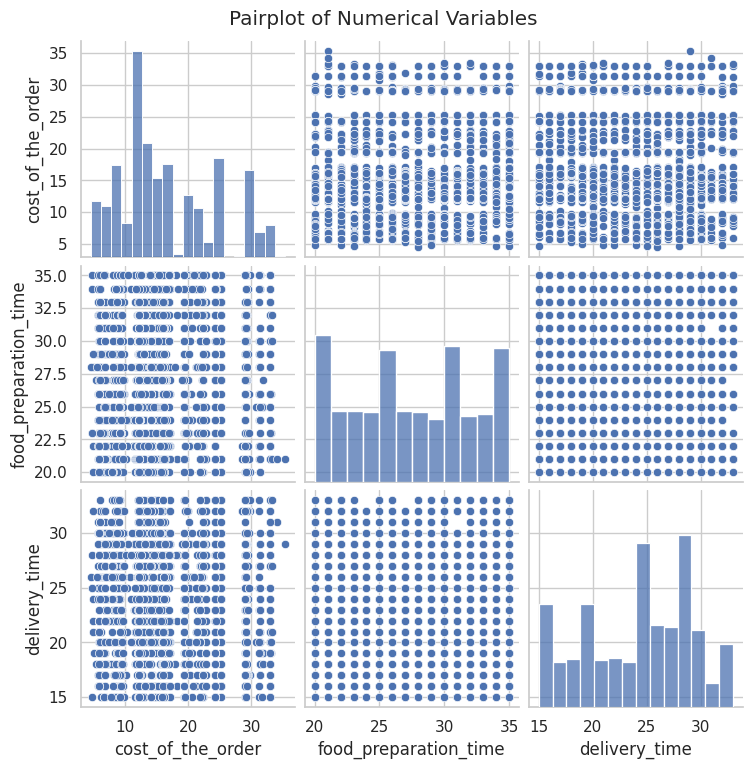

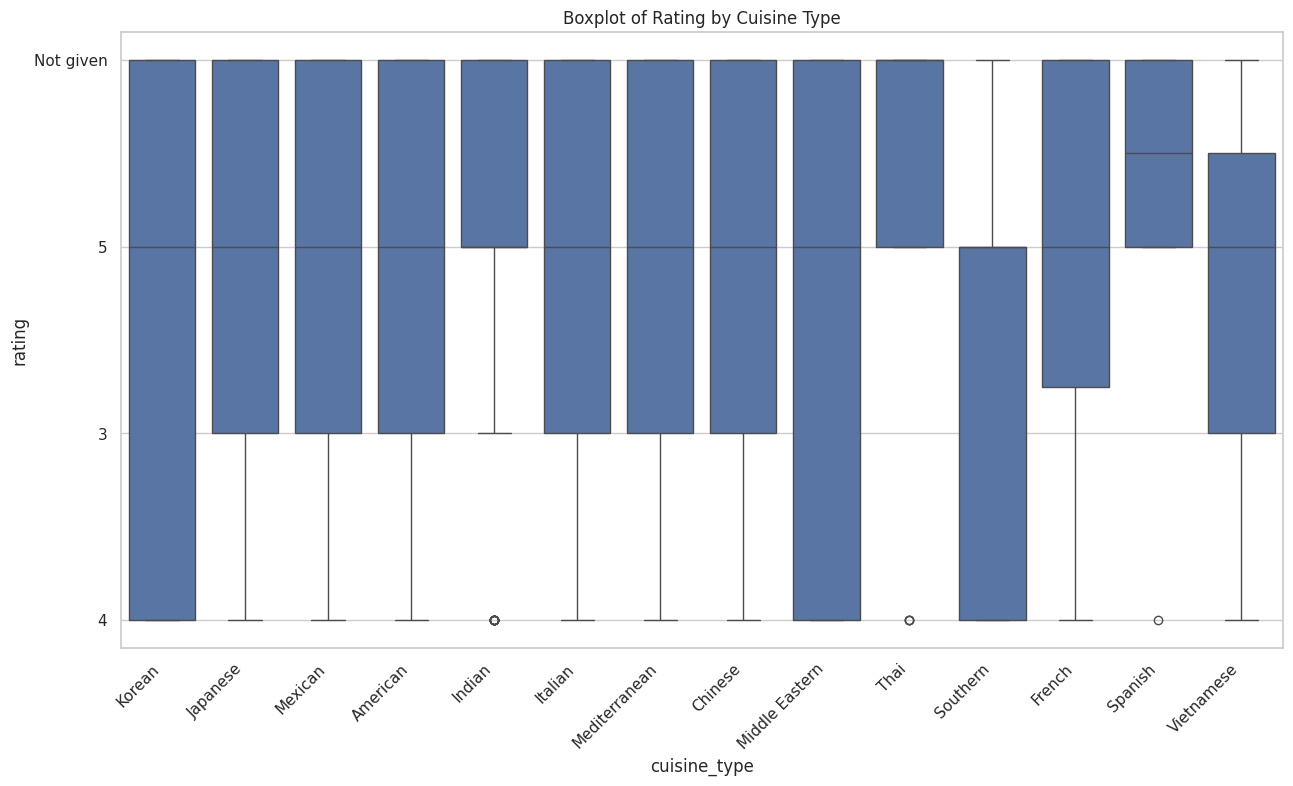

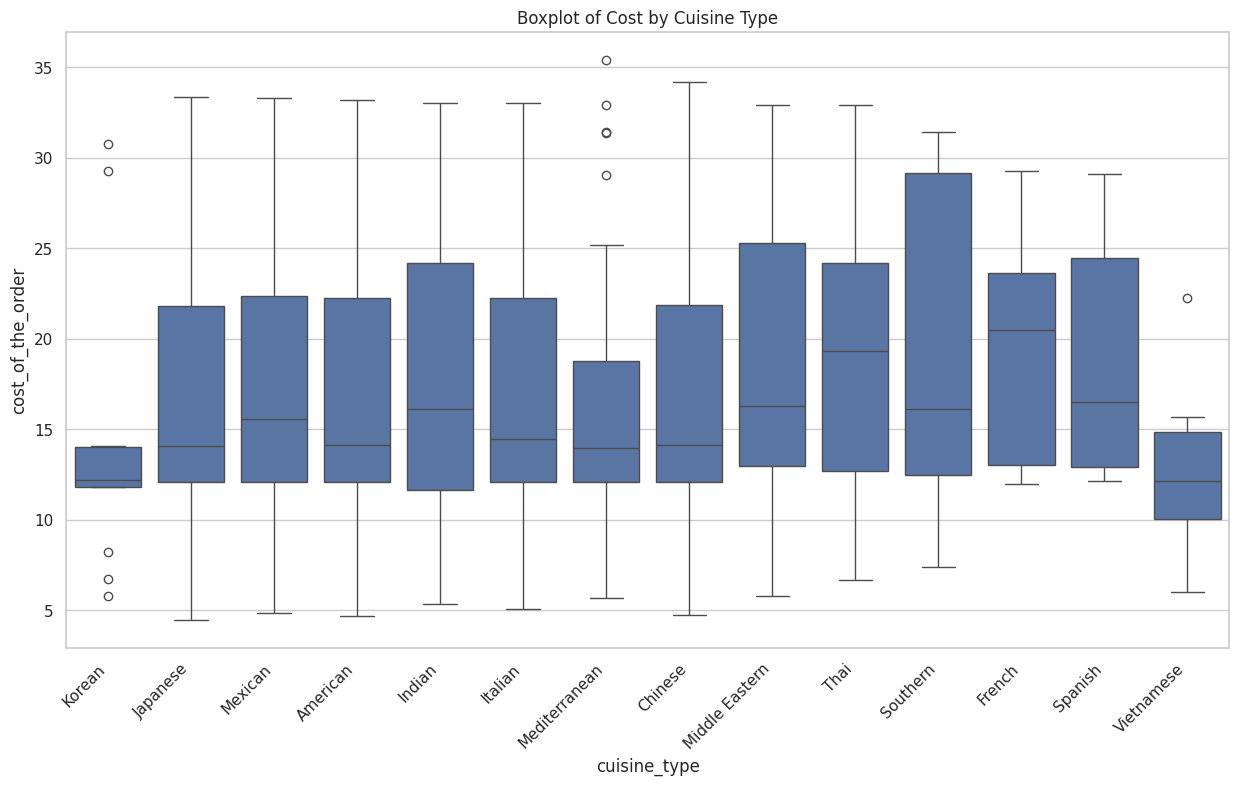

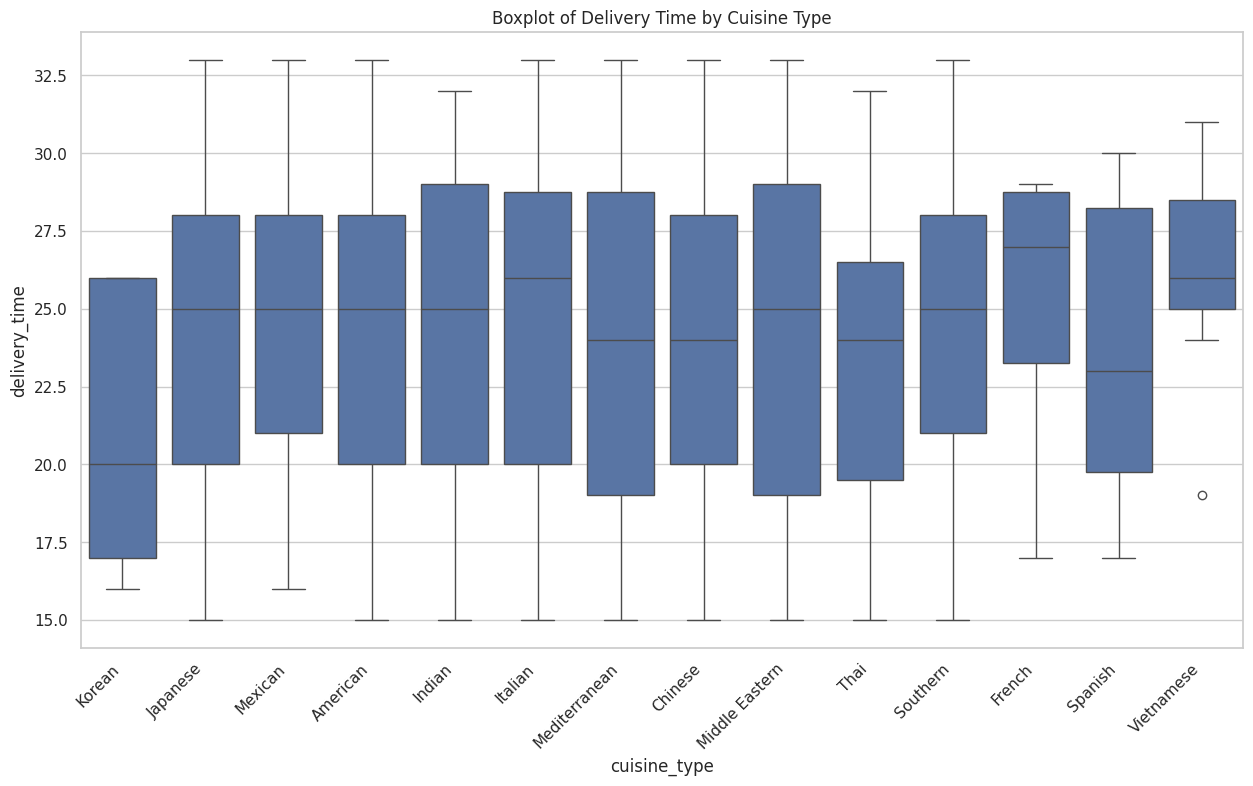

In [ ]:
# Write the code here
# Setting the style for seaborn
sns.set(style="whitegrid")

# Pairplot to visualize relationships between numerical variables
numerical_variables = ['cost_of_the_order', 'rating', 'food_preparation_time', 'delivery_time']
sns.pairplot(data[numerical_variables])
plt.suptitle("Pairplot of Numerical Variables", y=1.02)
plt.show()

# Boxplot to explore the relationship between rating and cuisine type
plt.figure(figsize=(15, 8))
sns.boxplot(x='cuisine_type', y='rating', data=data)
plt.title('Boxplot of Rating by Cuisine Type')
plt.xticks(rotation=45, ha='right')
plt.show()

# Boxplot to explore the relationship between cost and cuisine type
plt.figure(figsize=(15, 8))
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=data)
plt.title('Boxplot of Cost by Cuisine Type')
plt.xticks(rotation=45, ha='right')
plt.show()

# Boxplot to explore the relationship between delivery time and cuisine type
plt.figure(figsize=(15, 8))
sns.boxplot(x='cuisine_type', y='delivery_time', data=data)
plt.title('Boxplot of Delivery Time by Cuisine Type')
plt.xticks(rotation=45, ha='right')
plt.show()


In [ ]:
# Write the code here
import numpy as np

# Replacing non-numeric values with NaN in the 'rating' column
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')

# Calculating rating count and average rating for each restaurant
restaurant_stats = data.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Filtering restaurants based on the criteria
eligible_restaurants = restaurant_stats[(restaurant_stats['count'] > 50) & (restaurant_stats['mean'] > 4)]

# Displaying the restaurants fulfilling the criteria
print("Restaurants Eligible for Promotional Offer:")
print(eligible_restaurants)



Restaurants Eligible for Promotional Offer:
                           count      mean
restaurant_name                           
Blue Ribbon Fried Chicken     64  4.328125
Blue Ribbon Sushi             73  4.219178
Shake Shack                  133  4.278195
The Meatball Shop             84  4.511905


In [ ]:
# Write the code here
# Defining the charging percentages
charge_percentage_25 = 0.25
charge_percentage_15 = 0.15

# Calculating the charges for each order
data['charges'] = np.where(data['cost_of_the_order'] > 20, data['cost_of_the_order'] * charge_percentage_25,
                           np.where(data['cost_of_the_order'] > 5, data['cost_of_the_order'] * charge_percentage_15, 0))

# Calculating net revenue by subtracting charges from the cost
data['net_revenue'] = data['cost_of_the_order'] - data['charges']

# Calculating total net revenue
total_net_revenue = data['net_revenue'].sum()

print(f"The total net revenue generated by the company across all orders is: ${total_net_revenue:.2f}")


The total net revenue generated by the company across all orders is: $25148.52


In [ ]:
# Write the code here
# Calculating total time required for each order (food preparation time + delivery time)
data['total_delivery_time'] = data['food_preparation_time'] + data['delivery_time']

# Calculating the percentage of orders taking more than 60 minutes
percentage_orders_gt_60_minutes = (data[data['total_delivery_time'] > 60].shape[0] / data.shape[0]) * 100

print(f"The percentage of orders taking more than 60 minutes to get delivered is: {percentage_orders_gt_60_minutes:.2f}%")


The percentage of orders taking more than 60 minutes to get delivered is: 10.54%


In [ ]:
# Write the code here
# Creating a new column indicating whether the order is placed on a weekday or weekend
data['weekend'] = np.where(data['day_of_the_week'].isin(['Weekend']), True, False)

# Calculating the mean delivery time for weekdays and weekends
mean_delivery_time_weekdays = data[data['weekend'] == False]['delivery_time'].mean()
mean_delivery_time_weekends = data[data['weekend'] == True]['delivery_time'].mean()

print(f"The mean delivery time on weekdays is: {mean_delivery_time_weekdays:.2f} minutes")
print(f"The mean delivery time on weekends is: {mean_delivery_time_weekends:.2f} minutes")


The mean delivery time on weekdays is: 28.34 minutes
The mean delivery time on weekends is: 22.47 minutes


---

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn import model_selection
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import warnings
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization
from scikeras.wrappers import KerasClassifier
import random
from tensorflow.keras import backend
random.seed(1)
np.random.seed(1)
tf.random.set_seed(1)
warnings.filterwarnings("ignore")

In [ ]:
!pip install scikeras